In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd; pd.set_option("display.max_columns", None)
import sys;sys.path.append("..")
from config import Paths
from dataframes import *
from eals_data.utils import venn_diagram
from eals_radcliff.utils import dataframes as radcliff_dataframes
from eals_radcliff.utils import dataframes_paper as radcliff_dataframes_paper

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from eals_radcliff.models.LMM import model as lmm_model

# ALSFRS-R

In [4]:
feature='ALS_total'
XLIM = (-.1, 2)
YLIM = (0, 1.7)

### RAPA

In [19]:
df_als = load_alsfrsr_data()
df_als[f'{feature}_zscore'] = (df_als[feature] - df_als[feature].mean()) / df_als[feature].std()
print(f'N pALS: {df_als.user_id.nunique()}, N sessions: {df_als.session_id.nunique()}')
df_als.head(2)

N pALS: 11, N sessions: 88


,speech,salvation,swallowing,handwriting,cutting_food_a,cutting_food_b,dressing_and_hygiene,turning_in_bed,walking,climbing_stairs,dyspnea,orthopnea,respiratory_insufficiency,ALS_total,created_at,user_id,date,bulbar_subscore,respiratory_subscore,fine_motor_subscore,gross_motor_subscore,session_id,months_since_first_session,years_since_first_session,ALS_total_zscore
0,4,4,4,3,3,3.0,3,3,3,0,4,4,4,39,2025-07-10 20:27:25+00:00,a07848cb-83b1-48ef-a314-ae5b5e5d448b,2025-07-10,12,12,12.0,6,a07848cb-83b1-48ef-a314-ae5b5e5d448b__2025-07-10,13.733333,1.144444,1.197163
1,4,4,4,3,3,3.0,3,3,3,0,4,4,4,39,2025-06-12 16:25:16+00:00,a07848cb-83b1-48ef-a314-ae5b5e5d448b,2025-06-12,12,12,12.0,6,a07848cb-83b1-48ef-a314-ae5b5e5d448b__2025-06-12,12.800000,1.066667,1.197163


ALS_total ~ years_since_first_session
1 + years_since_first_session


                     Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         ALS_total
No. Observations:          88              Method:                     REML     
No. Groups:                11              Scale:                      1.4483   
Min. group size:           1               Log-Likelihood:             -167.3947
Max. group size:           28              Converged:                  Yes      
Mean group size:           8.0                                                  
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             25.132    2.650  9.483 0.000 19.938 30.326
years_since_first_session             -0.878    0.469 -1.874 0.061 -1.797  0.040
Group Var                             76.527   29.

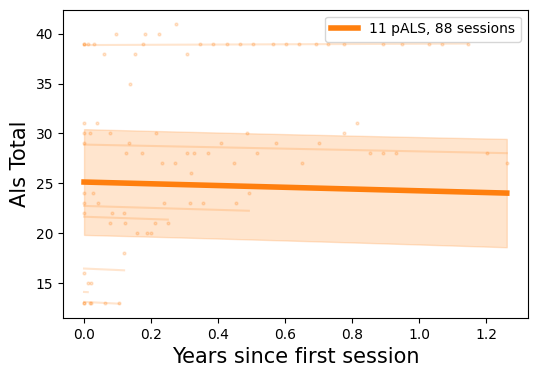

Population	Intercept (SE)	Slope (SE) (1/Years)
11 pALS, 88 sessions	25.132 (2.650)	-0.878 (0.469)


In [6]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()}"
result_dict = lmm_model.run_lmm_analysis(
    df_als,
    dependant_variable= feature,
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

ALS_total_zscore ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       ALS_total_zscore
No. Observations:       88            Method:                   REML            
No. Groups:             11            Scale:                    0.0207          
Min. group size:        1             Log-Likelihood:           15.3467         
Max. group size:        28            Converged:                Yes             
Mean group size:        8.0                                                     
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.459    0.317 -1.451 0.147 -1.080  0.161
years_since_first_session             -0.105    0.056 -1

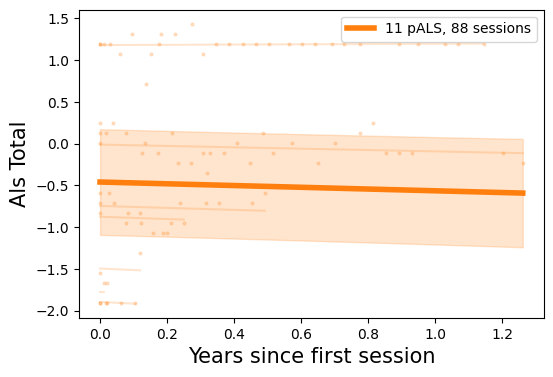

Population	Intercept (SE)	Slope (SE) (1/Years)
11 pALS, 88 sessions	-0.459 (0.317)	-0.105 (0.056)


In [20]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()}"
result_dict = lmm_model.run_lmm_analysis(
    df_als,
    dependant_variable= f'{feature}_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

### Radcliff

In [7]:
df_als_radcliff = radcliff_dataframes.load_alsfrsr_data()

# Compute months since the first session per user (vectorized)
first_date = df_als_radcliff.groupby('user_id')['date'].transform('min')
months = (df_als_radcliff['date'] - first_date) / np.timedelta64(30, 'D')  # ~months as float
df_als_radcliff.loc[:, 'months_since_first_session'] = months
df_als_radcliff.loc[:, 'years_since_first_session'] = df_als_radcliff['months_since_first_session'] / 12.0

ALS_total ~ years_since_first_session
1 + years_since_first_session


                     Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         ALS_total 
No. Observations:         1298            Method:                     REML      
No. Groups:               70              Scale:                      2.6759    
Min. group size:          1               Log-Likelihood:             -2698.8980
Max. group size:          99              Converged:                  Yes       
Mean group size:          18.5                                                  
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             40.839    0.676 60.444 0.000 39.515 42.163
years_since_first_session             -5.221    0.885 -5.899 0.000 -6.955 -3.486
Group Var                             30.846    3.

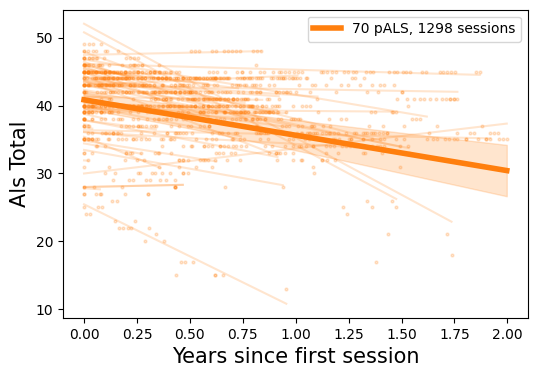

Population	Intercept (SE)	Slope (SE) (1/Years)
70 pALS, 1298 sessions	40.839 (0.676)	-5.221 (0.885)


In [8]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()}"
result_dict = lmm_model.run_lmm_analysis(
    df_als_radcliff,
    dependant_variable= feature,
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

### Both

In [9]:
df1 = df_als_radcliff[['user_id', 'years_since_first_session', 'date', 'session_id', feature]]
df1['is_radcliff'] = True
df2 = df_als[['user_id', 'years_since_first_session', 'date', 'session_id', feature]]
df2['is_radcliff'] = False
df_fix = pd.concat([df1, df2], ignore_index=True)

ALS_total ~ years_since_first_session*is_radcliff
1 + years_since_first_session
                      Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         ALS_total 
No. Observations:          1386            Method:                     REML      
No. Groups:                80              Scale:                      2.6147    
Min. group size:           1               Log-Likelihood:             -2896.1327
Max. group size:           99              Converged:                  Yes       
Mean group size:           17.3                                                  
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                              36.951    1.357 27.226 0.000 34.291 39.611
years_since_first_session              -

label_false:  RAPA (11 pALS, 88 sessions)


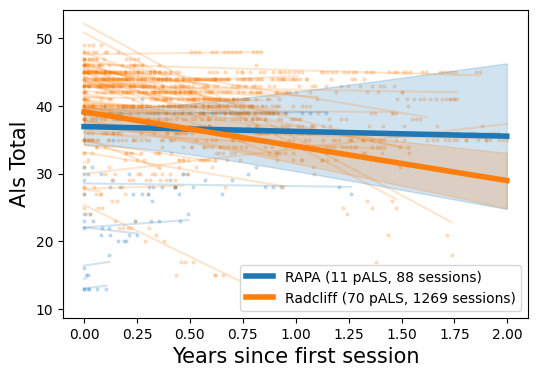

Population	Intercept (SE)	Slope (SE) (1/Years)
RAPA (11 pALS, 88 sessions)	36.951 (1.357)	-0.709 (2.606)
Radcliff (70 pALS, 1269 sessions)	39.130 (0.874)	-5.081 (0.923)
Interaction	2.179 (1.218)	-4.372 (2.765)


In [10]:
label_false = 'RAPA'
label_true = 'Radcliff' 
grouping_variable = 'is_radcliff'

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = f"{feature.replace('_',' ').replace('right','R').title()}"
result_dict = lmm_model.run_lmm_analysis(
    df_fix,
    dependant_variable= feature,
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    label_true= label_true,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

# ROADS

In [22]:
df_roads = load_roads_data()
df_roads['total_zscore'] = (df_roads['total'] - df_roads['total'].mean()) / df_roads['total'].std()
# Compute months since the first session per user (vectorized)
first_date = df_roads.groupby('user_id')['date'].transform('min')
months = (df_roads['date'] - first_date) / np.timedelta64(30, 'D')  # ~months as float
df_roads.loc[:, 'months_since_first_session'] = months
df_roads.loc[:, 'years_since_first_session'] = df_roads['months_since_first_session'] / 12.0

total ~ years_since_first_session
1 + years_since_first_session
                      Mixed Linear Model Regression Results
Model:                     MixedLM          Dependent Variable:          total    
No. Observations:          88               Method:                      REML     
No. Groups:                11               Scale:                       3.6640   
Min. group size:           1                Log-Likelihood:              -209.1063
Max. group size:           28               Converged:                   Yes      
Mean group size:           8.0                                                    
----------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
----------------------------------------------------------------------------------
Intercept                              23.217    3.139  7.397 0.000  17.065 29.369
years_since_first_session              -4.770 

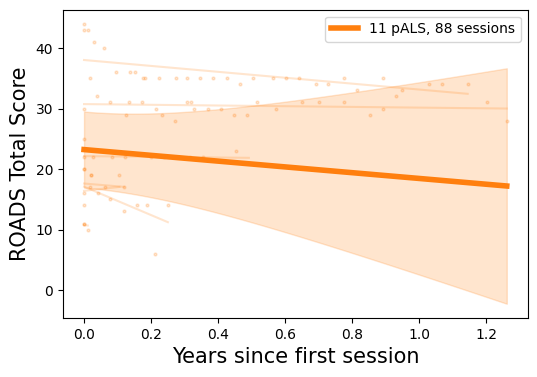

Population	Intercept (SE)	Slope (SE) (1/Years)
11 pALS, 88 sessions	23.217 (3.139)	-4.770 (7.294)


In [23]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = "ROADS Total Score"
result_dict = lmm_model.run_lmm_analysis(
    df_roads,
    dependant_variable= 'total',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()

total_zscore ~ years_since_first_session
1 + years_since_first_session
                     Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        total_zscore
No. Observations:         88             Method:                    REML        
No. Groups:               11             Scale:                     0.0504      
Min. group size:          1              Log-Likelihood:            -24.8248    
Max. group size:          28             Converged:                 Yes         
Mean group size:          8.0                                                   
--------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------
Intercept                             -0.537    0.368 -1.459 0.145 -1.259  0.185
years_since_first_session             -0.560    0.856 -0.654

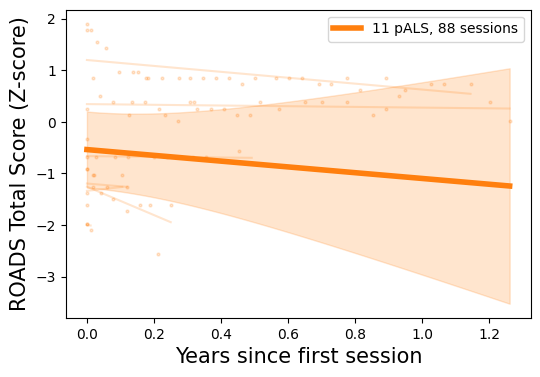

Population	Intercept (SE)	Slope (SE) (1/Years)
11 pALS, 88 sessions	-0.537 (0.368)	-0.560 (0.856)


In [24]:
label_false = None
label_true = False 
grouping_variable = None

if grouping_variable:
    colors = (sns.color_palette()[4], sns.color_palette()[3])
else:
    colors = None

dependant_variable_title = "ROADS Total Score (Z-score)"
result_dict = lmm_model.run_lmm_analysis(
    df_roads,
    dependant_variable= 'total_zscore',
    independent_variable= "years_since_first_session",
    grouping_variable= grouping_variable,
    label_false= label_false,
    dependant_variable_title=dependant_variable_title,
    plot= True,
    # xlim= XLIM,
    # ylim=YLIM,
    vary_intercept_and_slope= True,
    axis_labels= ['Years since first session', dependant_variable_title],
)
plt.show()